# Boosting Decision Trees

Bagging and Random Forest methods are examples of **ensemble methods**: methods that combine predicitons from groups of individual models to create more accurate and robust predictions. The indivual models are known as **base learners** or **weak learners**.  

Bagging  achieves this through variance reduction: it trains independent models on bootstrap samples and averages their predictions. **Boosting** takes a different approach. 

**Core idea of boosting: Train a sequence of models, where each successive model focuses its attention specifically on the mistakes made by the ensemble so far. Accuracy accumulates incrementally as the previous errors are corrected**

Boosting was first proposed in the paper *A Decision-Theoretic Generalization of On-Line Learning and an Application to Boosting* by Freund and Schapire. The paper starts with this text:

*A gambler, frustrated by persistent horse-racing losses
and envious of his friends' winnings, decides to allow a
group of his fellow gamblers to make bets on his behalf. He
decides he will wager a fixed sum of money in every race, but
that he will apportion his money among his friends based on
how well they are doing. Certainly, if he knew psychically
ahead of time which of his friends would win the most, he
would naturally have that friend handle all his wagers.
Lacking such clairvoyance, however, he attempts to allocate
each race's wager in such a way that his total winnings for
the season will be reasonably close to what he would have
won had he bet everything with the luckiest of his friends.*

They then go on to develop an algorithm, **AdaBoost** for accomplishing this goal. 

### Weak learners and decision stumps

A weak learner is any classifier (or regressor) that performs only marginally better than chance. For classification, this means error rate slightly below 50%. The canonical weak learner for boosting is the decision stump: a decision tree of depth 1, which partitions the feature space with a single split based on one variable. 

A typical decision stump based on predictor $x_j$ has form

$$
h(x_j) = \begin{cases} 
  \text{predict class A} & \text{if } x_j \ge t_j \\
  \text{predict class B} & \text{otherwise} 
\end{cases}
$$


What do we do with stumps? Here is more text copied from the AdaBoost paper that describes the problem well:


*Returning to the horse-racing story, suppose now that the
gambler grows weary of choosing among the experts and
instead wishes to create a computer program that will
accurately predict the winner of a horse race based on the
usual information (number of races recently won by each
horse, betting odds for each horse, etc.). To create such a
program, he asks his favorite expert to explain his betting
strategy. Not surprisingly, the expert is unable to articulate
a grand set of rules for selecting a horse. On the other hand,
when presented with the data for a specific set of races, the
expert has no trouble coming up with a ``rule-of-thumb'' for
that set of races (such as, ``Bet on the horse that has recently
won the most races'' or ``Bet on the horse with the most
favored odds''). Although such a rule-of-thumb, by itself, is
obviously very rough and inaccurate, it is not unreasonable
to expect it to provide predictions that are at least a little bit
better than random guessing. Furthermore, by repeatedly
asking the expert's opinion on different collections of races,
the gambler is able to extract many rules-of-thumb.
In order to use these rules-of-thumb to maximum advan-
tage, there are two problems faced by the gambler: First,
how should he choose the collections of races presented to
the expert so as to extract rules-of-thumb from the expert
that will be the most useful? Second, once he has collected
many rules-of-thumb, how can they be combined into a
single, highly accurate prediction rule?
Boosting refers to this general problem of producing a
very accurate prediction rule by combining rough and
moderately inaccurate rules-of-thumb.*
                                   
                                   
### AdaBoost Algorithm ##     

0. Initialize Weights: Every training sample is initially assigned an equal weight.  
1. Train Weak Learner: A simple model (e.g., a tree with only one split) is trained to classify the data.  
2. Identify Errors: The algorithm identifies which samples were misclassified by this model.  
3. Update Sample Weights: Misclassified samples are given higher weights (made more important) so the next learner focuses more on correcting those specific mistakes.  
4. Assign Model Weights $(\alpha)$:  More accurate weak learners are given higher influence in the final ensemble.  
5. Repeat: Steps 1–4 are repeated for a set number of iterations.  

Final Prediction: All weak learners "vote" on the classification, with their votes weighted by their individual accuracy $(\alpha)$.


#### More detail
Input: Training data $\{(x_i,y_i)\}_{i=1}^n$
                                   
                                   
                               
Initialize: weights $w_1(i) = 1/n$ for all i

For b = 1, 2, ..., B: 
1. Fit weak learner $G_b$ to data using weights $w_b$

2. Compute weighted error:
$$\epsilon_b=\frac{\sum_i w_i*I(G_b(x_i) \neq y_i)}{\sum_{i=1}^N w_i}$$

3. Compute learner weight:
$$\alpha_t=\frac{1}{2}ln\left(\frac{1-\epsilon_t}{\epsilon_t}\right)$$

4. Update sample weights:
$$w_{b+1}=w_b \exp(\alpha_b I(y_i \neq G_b(x_i)),  i=1..N$$

(misclassified examples gain weight, correct ones lose it)


Output: 
$$G(x)=\text{sign}\left[\sum_{b=1}^B\alpha_b G_b(x)\right]$$


#### The effect of the error rate

The learner weight $\alpha_b$ decreases with the error rate. 

Text(0, 0.5, 'learner weight')

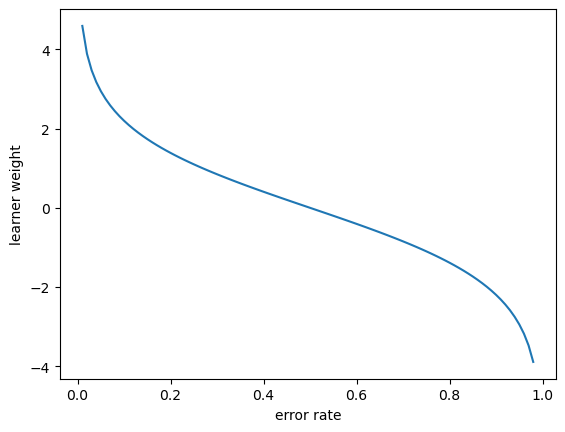

In [8]:
eseq=np.arange(0.01,0.99,0.01)
plt.plot(eseq,np.log((1-eseq)/eseq))
plt.xlabel("error rate")
plt.ylabel("learner weight")
plt.title("learner weight and error rate")

Note that $\alpha_b$ is fixed within an iteration.  All incorrectly classified data points are upweighted the same amount. The magnitude of the upweighting depends on the error rate. The lower the error weight, the more misclassified points are upweighted. Note that he upweighting is cimulative - if points are misclassified for multiple iterations, then their weight gets progressively larger. 

### Simulation Demonstration of AdaBoost


Next, we will go through an example demonstrating the steps of AdaBoost with simulated data. We will make plots that show how the weights evolve over time.  

Start by making simulated data:

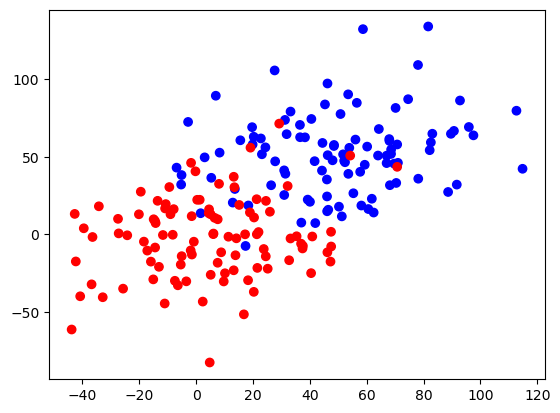

In [1]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from matplotlib.colors import ListedColormap

n=200 #sample size
muA=[50,50] #mean for class A
muB=[0,0] # mean for class B
sd1=25 #standard deviation
sd2=25
cor0=0.2
#covmat=[[sd1^2,cor0*sd1*sd2],[cor0*sd1*sd2,sd2^2]]
covmat = [[sd1**2, cor0*sd1*sd2], [cor0*sd1*sd2, sd2**2]] 

xA=npr.multivariate_normal(mean=muA,cov=covmat,size=int(n/2))
xB=npr.multivariate_normal(mean=muB,cov=covmat,size=int(n/2))
X=np.concatenate((xA,xB),axis=0)
y=np.concatenate((np.repeat(-1,int(n/2)),np.repeat(1,int(n/2))))

plt.figure()
cmap = ListedColormap(['blue', 'red'])
plt.scatter(X[:,0],X[:,1],c=y, cmap=cmap)


The remaining code will be completed in class. 

In [10]:
#Code completed in class

The image below is from the code example. It shows more weight is put on the hardest to classify points. 

In [11]:
from IPython.display import Image

![title](figures/WeightFigure.png)

This image shows the classes for the simulated data in the top figure and the predictions in the bottom figure. 

![title](figures/Figure_2.png)

The prediction does very well, even at the boundary. The only missclassified points are those deep in the "wrong" region and it is not reasonable to expect the classifier to get those correct. 

### Application to Titanic Data

Next, we will see how to do AdaBoost in `sklearn` with the Titanic data. 

In [12]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np


titanic=pd.read_csv("TitanicFinal.csv")
titanic



,survived,pclass,sex,age,fare,embarked,FamilySize
0,1,1,0,29.0000,3.0,0,0
1,1,1,1,0.9167,3.0,0,3
2,0,1,0,2.0000,3.0,0,3
3,0,1,1,30.0000,3.0,0,3
4,0,1,0,25.0000,3.0,0,3
...,...,...,...,...,...,...,...
1304,0,3,0,14.5000,2.0,1,1
1305,0,3,0,NaN,2.0,1,1
1306,0,3,1,26.5000,0.0,1,0
1307,0,3,1,27.0000,0.0,1,0


Set up training and test data. I also include a step to impute missing values. 

In [13]:
X = titanic.drop(columns=["survived"])
y = titanic["survived"]

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
X=X_imputed

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=12)

We will use the `AdaBoostClassifer` function in `sklearn`. The syntax for this function is very similar to other classifier functions that we have used in `sklearn`. 

In [14]:
clfAda = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=12)
clfAda.fit(X_train, y_train)

predictionsAda = clfAda.predict(X_test)
accuracy = clfAda.score(X_test, y_test)

In [15]:
accuracy

0.7900763358778626

In [16]:
print(classification_report(y_test,predictionsAda))

              precision    recall  f1-score   support

           0       0.83      0.82      0.83       159
           1       0.73      0.74      0.73       103

    accuracy                           0.79       262
   macro avg       0.78      0.78      0.78       262
weighted avg       0.79      0.79      0.79       262



AdaBoost performs slightly better than Random Forest with this data. The difference can be larger with more complex data. You will explore this more in the homework assignment. 

AdaBoost and related algorithms are considered one of the best "out-of-the-box" classifiers - that is it often performs very well with default parameters and minimal need for tuning. 